In [27]:
import numpy as np
import jax.numpy as jnp
import os
import matplotlib.pyplot as plt
import seaborn as sns
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70
rng = np.random.default_rng(13)

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

from project_utils import open_pickled_file, setup_matplotlib_styles

setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)
zh = jnp.linspace(0.0002, 0.2, len(tau))

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

path_figs = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/presentation'

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

def gaussian_burst(center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

def exp_decay(tau_scale):
    """Exponential decay with lookback time scale tau_scale (Gyr)."""
    return jnp.exp(-tau / tau_scale)

def smooth_random_sfr(k=5):
    """Random positive SFH: draw nonnegative coefficients and combine smooth bases."""
    # Smooth bases = wide Gaussians across 0..T_UNIV
    centers = np.linspace(0.1, T_UNIV*0.95, k)
    widths  = np.linspace(T_UNIV/12, T_UNIV/5, k)
    coeffs  = rng.lognormal(mean=-0.2, sigma=0.7, size=k)  # positive, varied
    s = jnp.zeros_like(tau)
    for c, w, a in zip(centers, widths, coeffs):
        s = s + a * jnp.exp(-0.5 * ((tau - c)/w)**2)
    return s / (jnp.mean(s) + 1e-12)


def bursty_sfr(n_bursts=(12, 20), width_range=(0.01, 0.15), floor_frac=1e-3):
    """
    Very bursty SFH as a sum of many narrow Gaussians in lookback time.
    - n_bursts: number of bursts (uniform integer in the given range)
    - width_range: Gaussian sigma range in Gyr (narrow -> bursty)
    - floor_frac: small constant floor as a fraction of mean burst level to avoid exact zeros
    """
    n = rng.integers(n_bursts[0], n_bursts[1]+1)
    centers = rng.uniform(low=0.0001, high=T_UNIV*0.5, size=n)          # Gyr (avoid exact edges)
    widths  = rng.uniform(low=width_range[0], high=width_range[1], size=n)  # Gyr
    amps    = rng.lognormal(mean=0.0, sigma=1.0, size=n)               # heavy-tail burst strengths

    s = jnp.zeros_like(tau)
    for c, w, a in zip(centers, widths, amps):
        s = s + a * jnp.exp(-0.5 * ((tau - c) / w) ** 2)

    # tiny floor to keep CSP/FSPS stable where interpolation or masking happens
    floor = floor_frac * jnp.mean(s + 1e-12)
    s = s + floor

    # normalize to unit mass over forward time t (or equivalently tau)
    s = s / (jnp.trapezoid(s, t) + 1e-30)
    return s


# 1) Very young (recent) — burst within last 50 Myr
sfr_young = gaussian_burst(center_tau=0.03, width_tau=0.02, amp=1.0)

# 2) Very old — early universe burst ~ 12 Gyr lookback
sfr_old = gaussian_burst(center_tau=12.0, width_tau=1.0, amp=1.0)

# 3) Young + old components (bimodal)
sfr_bimodal = (gaussian_burst(0.05, 0.03, 1.0) +
               gaussian_burst(11.0, 0.8, 0.7))

# 4) Very bursty — many narrow bursts
sfr_bursty = bursty_sfr()

# 5–6) Three random smooth SFHs
sfr_rand1 = smooth_random_sfr(k=6)

In [28]:
ssp_data.log_qq.shape

(12, 108)

In [29]:
dust_params = {'tau_pow': 0.2,
                'alpha': -1, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': 0.5, 'dust_index': 0}}
#emi_params = {'duste_qpah': 0.5, 
#              'duste_umin': 1.0, 
#              'duste_gamma': 0.01}
#init_dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp = CSPBasis(ssp_data, dusty=False, add_neb=False)

csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()


csp_att = CSPBasis(ssp_data, dusty=True, add_neb=False)

csp_att.add_sfh(sfr_bimodal, lookback_time=tau)
csp_att.add_zh(zh, lookback_time=tau)
spec_att = csp_att.get_spectrum(dust_params=dust_params)


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH
lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


In [ ]:
def plot_spectrum_and_sfh(csp, wave, spec, tau, sfr, 
                          spec_label="Dust-free spectrum", 
                          sfr_label="SFH", ylim=(1e-16, 1e-13)):
    
    csp.add_sfh(sfr, lookback_time=tau)
    csp.add_zh(zh, lookback_time=tau)
    spec = csp.get_spectrum(dust_params=dust_params)

    fig, axes = plt.subplots(1, 2, figsize=(30/3, 3), width_ratios=(2, 1))

    # Left: spectrum
    axes[0].plot(wave, fnu2flam(wave, spec * 1e-23 * 3631), '-', markersize=3,
                 label=spec_label, color="dodgerblue", markeredgecolor = 'blue')
    axes[0].set_yscale("log")
    axes[0].set_xlim(0, 10000)
    axes[0].set_ylim(ylim)
    axes[0].set_xlabel("Wavelength [Å]")
    axes[0].set_ylabel(r"$f_\lambda$")
    axes[0].legend()

    # Right: SFH
    axes[1].plot(tau, sfr, '-o', markeredgecolor='crimson', label=sfr_label, color="orange")
    axes[1].set_xlabel("Lookback Time [Gyr]")
    axes[1].set_ylabel("SFR")
    axes[1].legend()

    plt.tight_layout()
    return fig, axes

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


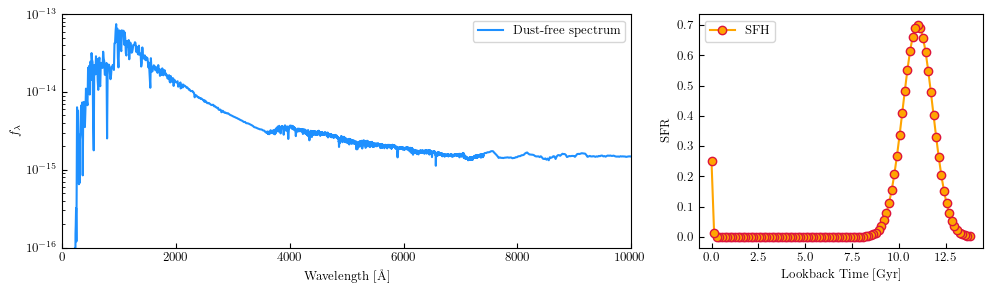

In [31]:
plot_spectrum_and_sfh(csp, csp.wave, spec, tau, sfr_bimodal)
plt.savefig(os.path.join(path_figs, 'spectrum_sfh_bimodal.png'), dpi=1200)

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


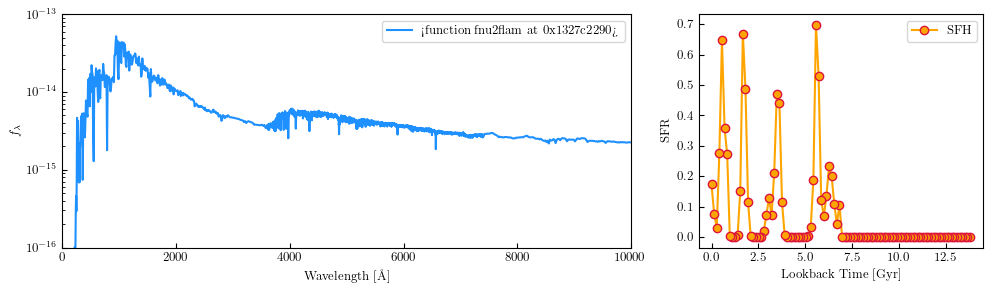

In [32]:
plot_spectrum_and_sfh(csp, csp.wave, spec, tau, sfr_bursty, fnu2flam)
plt.savefig(os.path.join(path_figs, 'spectrum_sfh_bursty.png'), dpi=1200)

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


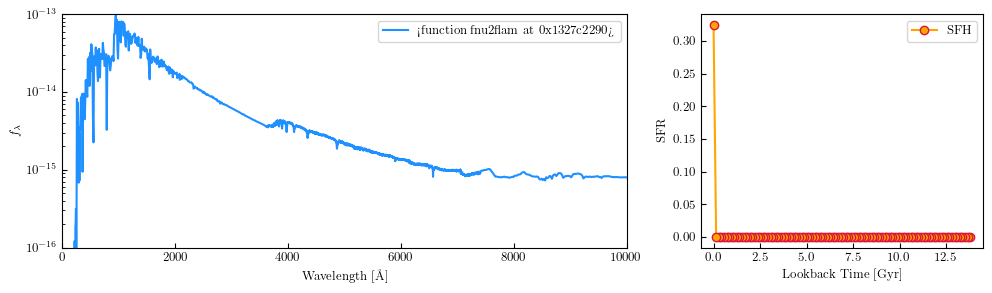

In [33]:
plot_spectrum_and_sfh(csp, csp.wave, spec, tau, sfr_young, fnu2flam)
plt.savefig(os.path.join(path_figs, 'spectrum_sfh_young.png'), dpi=1200)

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


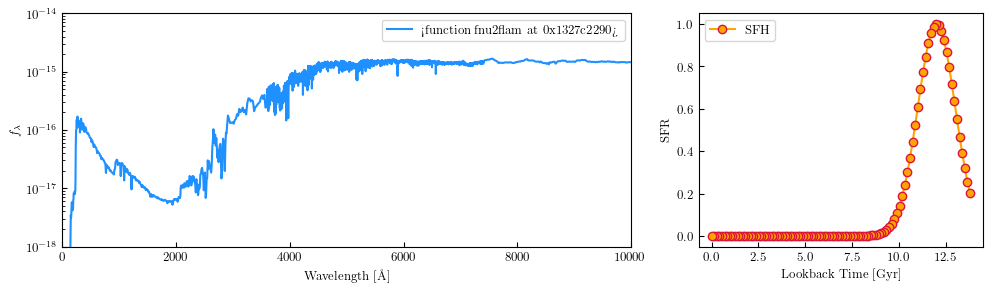

In [34]:
plot_spectrum_and_sfh(csp, csp.wave, spec, tau, sfr_old, fnu2flam, ylim=(1e-18, 1e-14))
plt.savefig(os.path.join(path_figs, 'spectrum_sfh_old.png'), dpi=1200)

# Add Dust Attenuation

In [35]:
csp = CSPBasis(ssp_data, dusty=False, add_neb=False)

init_dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']}
csp_att = CSPBasis(ssp_data, dusty=True, dust_params=init_dust_params)

dust_params = {'tau_pow': 1.0,
 'alpha': 1.0,
 'tau_kc': 0.5,
 'dust_index': 0.1,
 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}


dust_params_young = {'tau_pow': 1.0,
 'alpha': 1.0,
 'tau_kc': 0.0,
 'dust_index': 0.0,
 'diffuse_params': {'tau_kc': 0.0, 'dust_index': 0.0}}


dust_params_young_diffuse = {'tau_pow': 1.0,
 'alpha': 1.0,
 'tau_kc': 0.0,
 'dust_index': 0.0,
 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


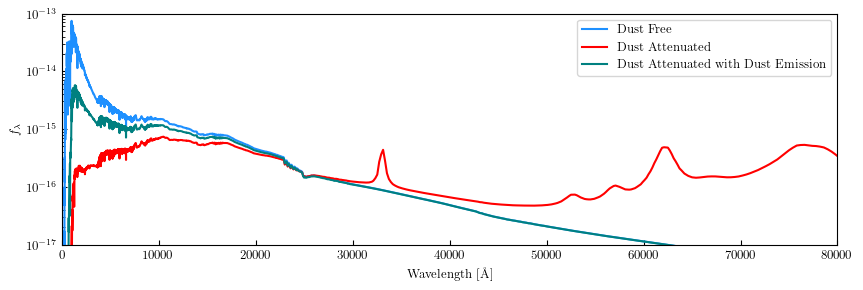

In [36]:
init_dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']}
csp_emi = CSPBasis(ssp_data, dusty=True, dust_params=init_dust_params, dust_emission=True, add_neb=False)

emi_params = {'duste_qpah': 4.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}

wave = csp.wave

this = sfr_bimodal


csp_emi.add_sfh(this, lookback_time=tau)
csp_emi.add_zh(zh, lookback_time=tau)
spec_emi = csp_emi.get_spectrum(dust_params=dust_params, emi_params=emi_params)


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(wave, fnu2flam(wave, spec * 1e-23 * 3631),
        '-', markersize=3, label='Dust Free',
        color="dodgerblue", markeredgecolor='blue')
ax.plot(wave, fnu2flam(wave, spec_emi * 1e-23 * 3631),
        '-', markersize=3, label='Dust Attenuated',
        color="red", markeredgecolor='blue')
ax.plot(wave, fnu2flam(wave, spec_att * 1e-23 * 3631),
        '-', markersize=3, label='Dust Attenuated with Dust Emission',
        color="teal", markeredgecolor='blue')

ax.set_yscale("log")
ax.set_xlim(0, 80000)
ax.set_ylim(1e-17, 1e-13)
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel(r"$f_\lambda$")
ax.legend()


plt.savefig(os.path.join(path_figs, 'spectrum_sfh_bimodal_dust_emission.png'), dpi=1200)

In [37]:
csp_neb = CSPBasis(ssp_data, dusty=False, dust_emission=False, add_neb=True)
csp_neb.add_sfh(this, lookback_time=tau)
csp_neb.add_zh(zh, lookback_time=tau)
spec_neb = csp_neb.get_spectrum_neb()
spec_noneb = csp_neb.get_spectrum_dustfree(neb_params = {'logZ': 0.0, 'logU': -2.0})

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


In [38]:
csp_neb.spectrum_noneb


Array([5.1657155e-14, 5.5174235e-14, 7.1084062e-14, ..., 1.9375689e-13,
       1.9019968e-13, 1.8669776e-13], dtype=float32)

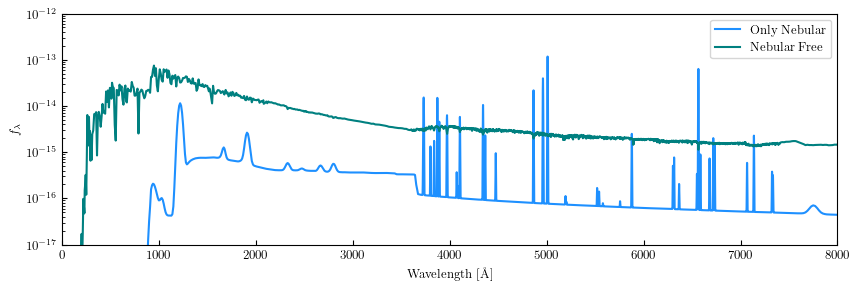

In [39]:


fig, ax = plt.subplots(figsize=(10, 3))




ax.plot(wave, fnu2flam(wave, (csp_neb.spectrum_neb)* 1e-23 * 3631),
        '-', markersize=3, label='Only Nebular',
        color="dodgerblue", markeredgecolor='dodgerblue')

ax.plot(wave, fnu2flam(wave, csp_neb.spectrum_noneb* 1e-23 * 3631),
        '-', markersize=3, label='Nebular Free',
        color="teal", markeredgecolor='teal')


ax.set_yscale("log")
ax.set_xlim(0, 8000)
ax.set_ylim(1e-17, 1e-12)
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel(r"$f_\lambda$")
ax.legend()


plt.savefig(os.path.join(path_figs, 'spectrum_sfh_bimodal_neb_emission.png'), dpi=1200)

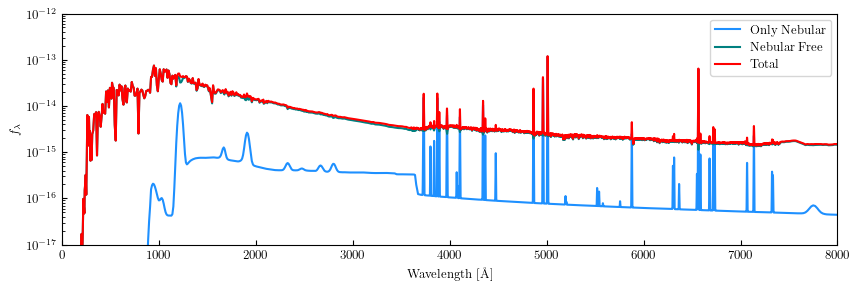

In [40]:


fig, ax = plt.subplots(figsize=(10, 3))




ax.plot(wave, fnu2flam(wave, (csp_neb.spectrum_neb)* 1e-23 * 3631),
        '-', markersize=3, label='Only Nebular',
        color="dodgerblue", markeredgecolor='dodgerblue')

ax.plot(wave, fnu2flam(wave, csp_neb.spectrum_noneb* 1e-23 * 3631),
        '-', markersize=3, label='Nebular Free',
        color="teal", markeredgecolor='teal')

ax.plot(wave, fnu2flam(wave, (spec_neb)* 1e-23 * 3631),
        '-', markersize=3, label='Total',
        color="red", markeredgecolor='red')

ax.set_yscale("log")
ax.set_xlim(0, 8000)
ax.set_ylim(1e-17, 1e-12)
ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel(r"$f_\lambda$")
ax.legend()


plt.savefig(os.path.join(path_figs, 'spectrum_sfh_bimodal_neb_emission_total.png'), dpi=1200)

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import jax.numpy as jnp
from textwrap import shorten

# ---------------- helpers ----------------

def _box(ax, xy, text, width=3.2, height=1.6, fontsize=9):
    """Draw a rounded box with centered text and return (patch, (w,h))."""
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width, height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.2, fill=False
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
    return patch, (width, height)

def _rect_anchor(center, size, toward):
    """
    Given a rectangle center (cx,cy), size (w,h), and a target point (tx,ty),
    return the point on the rectangle border in the direction of 'toward'.
    """
    cx, cy = center
    w, h = size
    tx, ty = toward
    dx, dy = tx - cx, ty - cy

    # If horizontal reach dominates, attach on left/right; else top/bottom.
    if abs(dx) / max(abs(dy), 1e-12) >= w / max(h, 1e-12):
        # use left/right edge
        x_edge = cx + (w / 2) * (1 if dx >= 0 else -1)
        # project y along the line, then clamp to rectangle vertical span
        y_proj = cy + (dy / (dx + 1e-12)) * (x_edge - cx)
        y_edge = min(max(y_proj, cy - h / 2), cy + h / 2)
        return (x_edge, y_edge)
    else:
        # use top/bottom edge
        y_edge = cy + (h / 2) * (1 if dy >= 0 else -1)
        x_proj = cx + (dx / (dy + 1e-12)) * (y_edge - cy)
        x_edge = min(max(x_proj, cx - w / 2), cx + w / 2)
        return (x_edge, y_edge)

def _arrow_edge_to_edge(ax, c_from, size_from, c_to, size_to):
    """Arrow that connects rectangle borders instead of centers."""
    p_from = _rect_anchor(c_from, size_from, c_to)
    p_to   = _rect_anchor(c_to,   size_to,   c_from)
    ax.add_patch(FancyArrowPatch(
        p_from, p_to, arrowstyle="-|>", mutation_scale=12, linewidth=1.0
    ))

def _fmt_shape(obj):
    """Return array shape if array-like, else str(obj)."""
    try:
        arr = jnp.asarray(obj)
        return str(arr.shape)
    except Exception:
        return str(obj)

def _fmt_list(xs, max_items=5):
    try:
        n = len(xs)
        head = [str(xs[i]) for i in range(min(n, max_items))]
        return (", ".join(head) + (" …" if n > max_items else "")) if n else "[]"
    except Exception:
        return str(xs)

def _fmt_kv(title, items, line_limit=120):
    lines = [title]
    for k, v in items:
        val = shorten(str(v), width=line_limit, placeholder="…")
        lines.append(f"{k}: {val}")
    return "\n".join(lines)

# ---------------- main plot ----------------

def plot_model_overview(model):
    """
    Visual overview of a CSP / SED-fitting model and its major components.
    Shows only shapes for arrays; arrows connect box edges.
    """
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    ax.axis("off")

    coords = {
        "SFH": (-6.2,  2.0),
        "SSPs": (-6.2, -1.6),
        "Dust": (-1.8,  2.0),
        "Emission": (-1.8, -1.6),
        "Combine": (1.9, 0.2),
        "Spectrum": (6.3, 0.2),
    }

    # -------- info blocks --------
    # SFH
    if hasattr(model, "sfh") and hasattr(model, "sfh_times"):
        sfh_info = _fmt_kv("SFH", [
            ("Times (lookback)", _fmt_shape(model.sfh_times)),
            ("Values", _fmt_shape(model.sfh)),
        ])
    else:
        sfh_info = "SFH\n * Not set"

    # SSPs
    ages = getattr(model, "ages", None)
    zmet = getattr(model, "zmet", None)
    ssp_info = _fmt_kv("SSP Grid", [
        ("Ages", _fmt_shape(ages) if ages is not None else "n/a"),
        ("Metallicities", _fmt_shape(zmet) if zmet is not None else "n/a"),
    ])

    # Dust attenuation (with laws if available)
    dust = getattr(model, "dust", None)
    if dust is not None:
        bin_edges = getattr(model, "bin_edges", getattr(dust, "bin_edges", None))
        laws = getattr(dust, "laws", None)
        dust_items = [
            ("Class", dust.__class__.__name__),
            ("Bins:", bin_edges if bin_edges is not None else "n/a"),
        ]
        if laws is not None:
            dust_items.append(("Laws", _fmt_list(laws)))
        dust_info = _fmt_kv("Dust", dust_items)
    else:
        dust_info = "Dust\n * None"

    # Dust emission
    emi = getattr(model, "emi", None)
    if emi is not None:
        emi_items = [("Class", emi.__class__.__name__)]
        for attr in ("duste_model", "nqpah", "dust_file"):
            if hasattr(emi, attr):
                emi_items.append((attr, getattr(emi, attr)))
        emission_info = _fmt_kv("Dust Emission", emi_items)
    else:
        emission_info = "Dust Emission\n * None"

    # Spectrum
    wave = getattr(model, "wave", None)
    spectrum = getattr(model, "spectrum", None)
    spec_info = _fmt_kv("Outputs", [
        ("Wave shape", _fmt_shape(wave) if wave is not None else "n/a"),
        ("Spectrum shape", _fmt_shape(spectrum) if spectrum is not None else "Not computed"),
    ])

    # -------- draw boxes --------
    b_sfh, size_sfh = _box(ax, coords["SFH"], sfh_info)
    b_ssp, size_ssp = _box(ax, coords["SSPs"], ssp_info)
    b_dust, size_dust = _box(ax, coords["Dust"], dust_info)
    b_emi, size_emi = _box(ax, coords["Emission"], emission_info)
    b_comb, size_comb = _box(ax, coords["Combine"], "Combine / Radiative Transfer\n * Attenuate + Add Emission")
    b_spec, size_spec = _box(ax, coords["Spectrum"], spec_info)

    # -------- edge-to-edge arrows --------
    _arrow_edge_to_edge(ax, coords["SFH"], size_sfh, coords["Combine"], size_comb)
    _arrow_edge_to_edge(ax, coords["SSPs"], size_ssp, coords["Combine"], size_comb)
    if dust is not None:
        _arrow_edge_to_edge(ax, coords["Dust"], size_dust, coords["Combine"], size_comb)
    if emi is not None:
        _arrow_edge_to_edge(ax, coords["Emission"], size_emi, coords["Combine"], size_comb)
    _arrow_edge_to_edge(ax, coords["Combine"], size_comb, coords["Spectrum"], size_spec)

    # frame
    ax.set_xlim(-8.5, 8.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_title("Model Overview", fontsize=32, fontweight='bold')
    return fig, ax

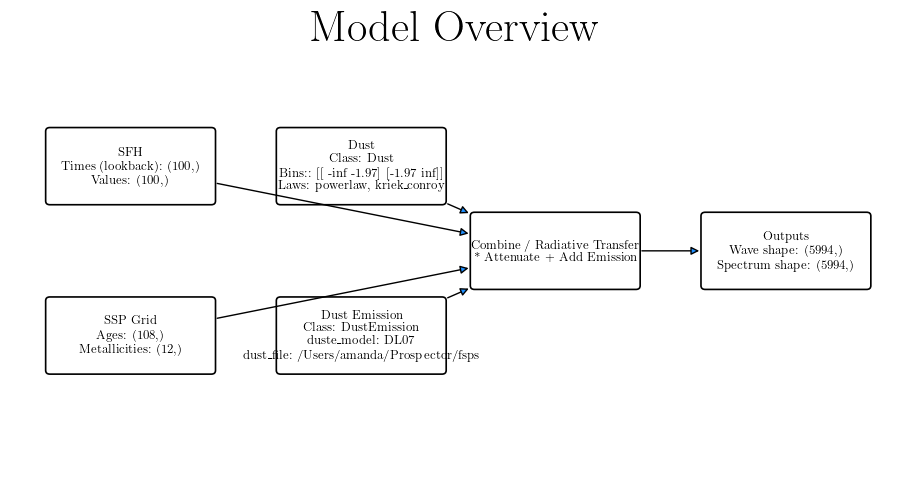

In [16]:
fig, ax = plot_model_overview(csp_emi)
fig.savefig("model_overview.png", dpi=300)

In [22]:
def _box(ax, xy, text, width=3.2, height=1.6, fontsize=9, **kwargs):
    """Draw a rounded box with centered text and return (patch, (w,h))."""
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width, height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.2,
        **kwargs
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
    return patch, (width, height)

def _rect_anchor(center, size, toward):
    """
    Given a rectangle center (cx,cy), size (w,h), and a target point (tx,ty),
    return the point on the rectangle border in the direction of 'toward'.
    """
    cx, cy = center
    w, h = size
    tx, ty = toward
    dx, dy = tx - cx, ty - cy

    # If horizontal reach dominates, attach on left/right; else top/bottom.
    if abs(dx) / max(abs(dy), 1e-12) >= w / max(h, 1e-12):
        # use left/right edge
        x_edge = cx + (w / 2) * (1 if dx >= 0 else -1)
        # project y along the line, then clamp to rectangle vertical span
        y_proj = cy + (dy / (dx + 1e-12)) * (x_edge - cx)
        y_edge = min(max(y_proj, cy - h / 2), cy + h / 2)
        return (x_edge, y_edge)
    else:
        # use top/bottom edge
        y_edge = cy + (h / 2) * (1 if dy >= 0 else -1)
        x_proj = cx + (dx / (dy + 1e-12)) * (y_edge - cy)
        x_edge = min(max(x_proj, cx - w / 2), cx + w / 2)
        return (x_edge, y_edge)

def _arrow_edge_to_edge(ax, c_from, size_from, c_to, size_to, **kwargs):
    """Arrow that connects rectangle borders instead of centers."""
    p_from = _rect_anchor(c_from, size_from, c_to)
    p_to   = _rect_anchor(c_to,   size_to,   c_from)
    ax.add_patch(FancyArrowPatch(
        p_from, p_to, arrowstyle="-|>", mutation_scale=12,**kwargs
    ))

def _fmt_shape(obj):
    """Return array shape if array-like, else str(obj)."""
    try:
        arr = jnp.asarray(obj)
        return str(arr.shape)
    except Exception:
        return str(obj)

def _fmt_list(xs, max_items=5):
    try:
        n = len(xs)
        head = [str(xs[i]) for i in range(min(n, max_items))]
        return (", ".join(head) + (" …" if n > max_items else "")) if n else "[]"
    except Exception:
        return str(xs)

def _fmt_kv(title, items, line_limit=120):
    lines = [title]
    for k, v in items:
        val = shorten(str(v), width=line_limit, placeholder="…")
        lines.append(f"{k}: {val}")
    return "\n".join(lines)

# ---------------- Main function to generate the plot ----------------

def plot_model_structure(model):
    """
    Creates a clean, elegant plot visualizing the components of a CSPBasis model.

    This function inspects the input model object and dynamically generates a
    flow-chart-style diagram, showing which physical components (like dust
    attenuation and emission) are included and their specific parameters.

    Args:
        model (CSPBasis): An instantiated CSPBasis model object.
    """
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    ax.axis("off")

    # Define colors for the different component types
    colors = {
        "input": "#B0C4DE",      # Light Steel Blue
        "attenuation": "#ADD8E6", # Light Blue
        "emission": "#FFB6C1",   # Light Pink
        "processing": "#90EE90", # Light Green
        "output": "#F0E68C",     # Khaki
    }

    coords = {
        "SFH": (-6.2,  2.0),
        "SSPs": (-6.2, -1.6),
        "Dust": (-1.8,  2.0),
        "Emission": (-1.8, -1.6),
        "Combine": (1.9, 0.2),
        "Spectrum": (6.3, 0.2),
    }

    # -------- info blocks --------
    # SFH
    sfh_info = "SFH\n * Not set"
    if hasattr(model, "sfh") and hasattr(model, "sfh_times"):
        sfh_info = _fmt_kv("Star Formation History", [
            ("Times (lookback)", _fmt_shape(model.sfh_times)),
            ("Values", _fmt_shape(model.sfh)),
        ])

    # SSPs
    ssp_info = "SSP Grid\n * Not set"
    ages = getattr(model, "ages", None)
    zmet = getattr(model, "zmet", None)
    if ages is not None and zmet is not None:
        ssp_info = _fmt_kv("Simple Stellar Populations", [
            ("Ages", _fmt_shape(ages)),
            ("Metallicities", _fmt_shape(zmet)),
        ])

    # Dust attenuation (with laws if available)
    dust_info = "Dust Attenuation\n * None"
    dust = getattr(model, "dust", None)
    if dust is not None:
        bin_edges = getattr(model, "bin_edges", getattr(dust, "bin_edges", None))
        laws = getattr(dust, "laws", None)
        dust_items = [
            ("Class", dust.__class__.__name__),
            ("Bins:", bin_edges if bin_edges is not None else "n/a"),
        ]
        if laws is not None:
            dust_items.append(("Laws", _fmt_list(laws)))
        dust_info = _fmt_kv("Dust Attenuation", dust_items)

    # Dust emission
    emission_info = "Dust Emission\n * None"
    emi = getattr(model, "emi", None)
    if emi is not None:
        emi_items = [("Class", emi.__class__.__name__)]
        for attr in ("duste_model", "nqpah", "dust_file"):
            if hasattr(emi, attr):
                emi_items.append((attr, getattr(emi, attr)))
        emission_info = _fmt_kv("Dust Emission", emi_items)

    # Spectrum
    spec_info = "Outputs\n * Not computed"
    wave = getattr(model, "wave", None)
    spectrum = getattr(model, "spectrum", None)
    if wave is not None or spectrum is not None:
        spec_info = _fmt_kv("Outputs", [
            ("Wave shape", _fmt_shape(wave) if wave is not None else "n/a"),
            ("Spectrum shape", _fmt_shape(spectrum) if spectrum is not None else "Not computed"),
        ])

    # -------- draw boxes --------
    b_sfh, size_sfh = _box(ax, coords["SFH"], sfh_info, fc=colors["input"], ec="k")
    b_ssp, size_ssp = _box(ax, coords["SSPs"], ssp_info, fc=colors["input"], ec="k")
    
    dust_color = colors["attenuation"] if dust is not None else "lightgray"
    b_dust, size_dust = _box(ax, coords["Dust"], dust_info, fc=dust_color, ec="k")
    
    emi_color = colors["emission"] if emi is not None else "lightgray"
    b_emi, size_emi = _box(ax, coords["Emission"], emission_info, fc=emi_color, ec="k")
    
    b_comb, size_comb = _box(ax, coords["Combine"], "Radiative Transfer\n * Attenuate + Add Emission", fc=colors["processing"], ec="k")
    b_spec, size_spec = _box(ax, coords["Spectrum"], spec_info, fc=colors["output"], ec="k")

    # -------- edge-to-edge arrows --------
    _arrow_edge_to_edge(ax, coords["SFH"], size_sfh, coords["Combine"], size_comb, color=colors["input"])
    _arrow_edge_to_edge(ax, coords["SSPs"], size_ssp, coords["Combine"], size_comb, color=colors["input"])
    if dust is not None:
        _arrow_edge_to_edge(ax, coords["Dust"], size_dust, coords["Combine"], size_comb, color=colors["attenuation"])
    if emi is not None:
        _arrow_edge_to_edge(ax, coords["Emission"], size_emi, coords["Combine"], size_comb, color=colors["emission"])
    _arrow_edge_to_edge(ax, coords["Combine"], size_comb, coords["Spectrum"], size_spec, color=colors["output"], linewidth=1.5)

    # frame
    ax.set_xlim(-8.5, 8.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_title("Galactic Model Flow Chart", fontsize=32, fontweight='bold', pad=20)
    
    # Add a simple legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, fc=colors["input"], ec="k", label='Inputs'),
        plt.Rectangle((0, 0), 1, 1, fc=colors["attenuation"], ec="k", label='Attenuation'),
        plt.Rectangle((0, 0), 1, 1, fc=colors["emission"], ec="k", label='Emission'),
        plt.Rectangle((0, 0), 1, 1, fc=colors["processing"], ec="k", label='Processing'),
        plt.Rectangle((0, 0), 1, 1, fc=colors["output"], ec="k", label='Output')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=False)
    
    plt.tight_layout()

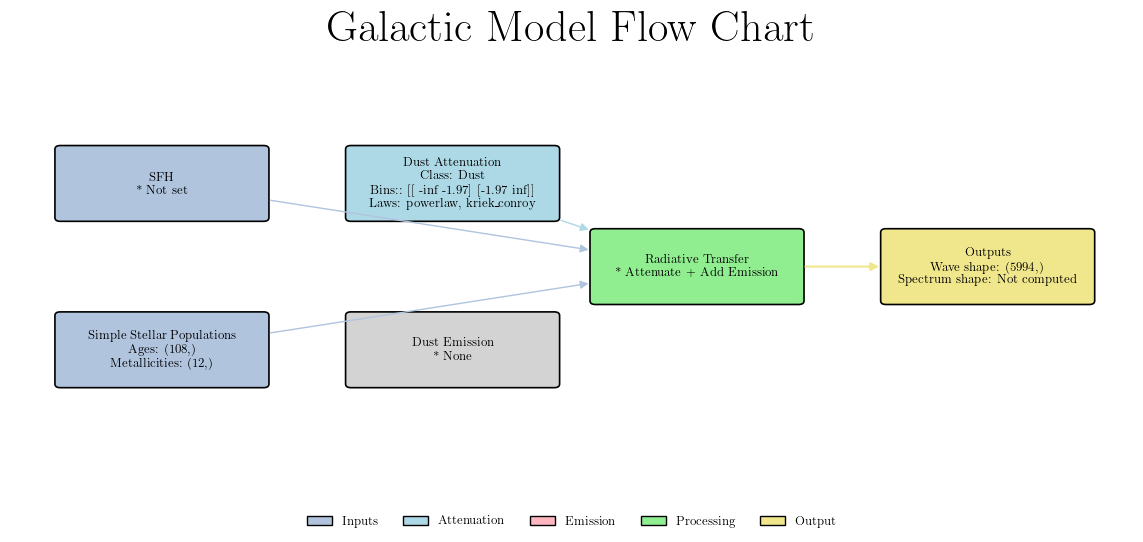

In [23]:
plot_model_structure(csp_att)
plt.savefig(os.path.join(path_figs, 'flow_csp_att.png'), dpi=300)

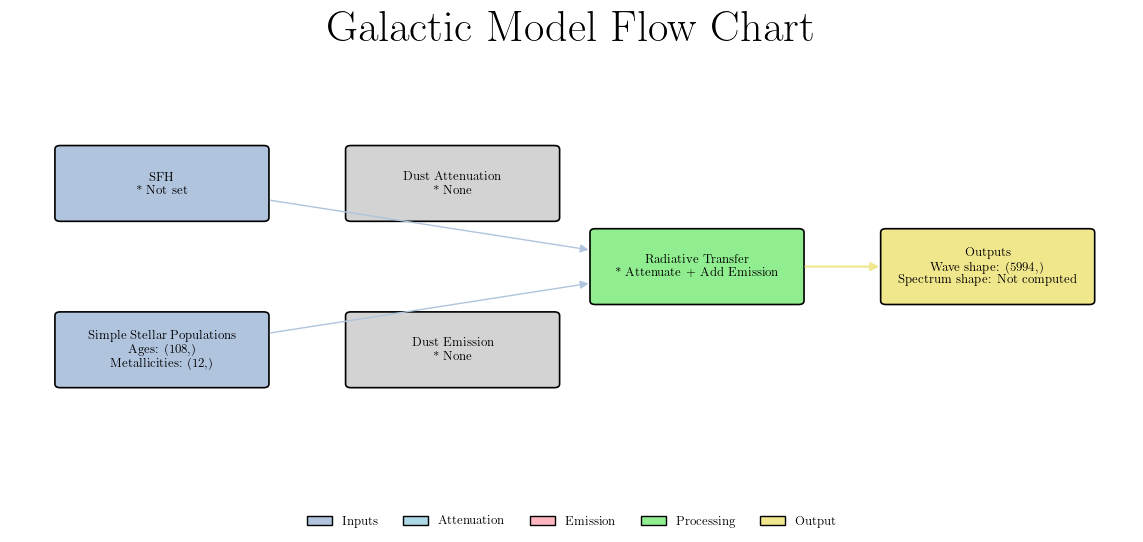

In [24]:
plot_model_structure(csp)
plt.savefig(os.path.join(path_figs, 'flow_csp.png'), dpi=300)

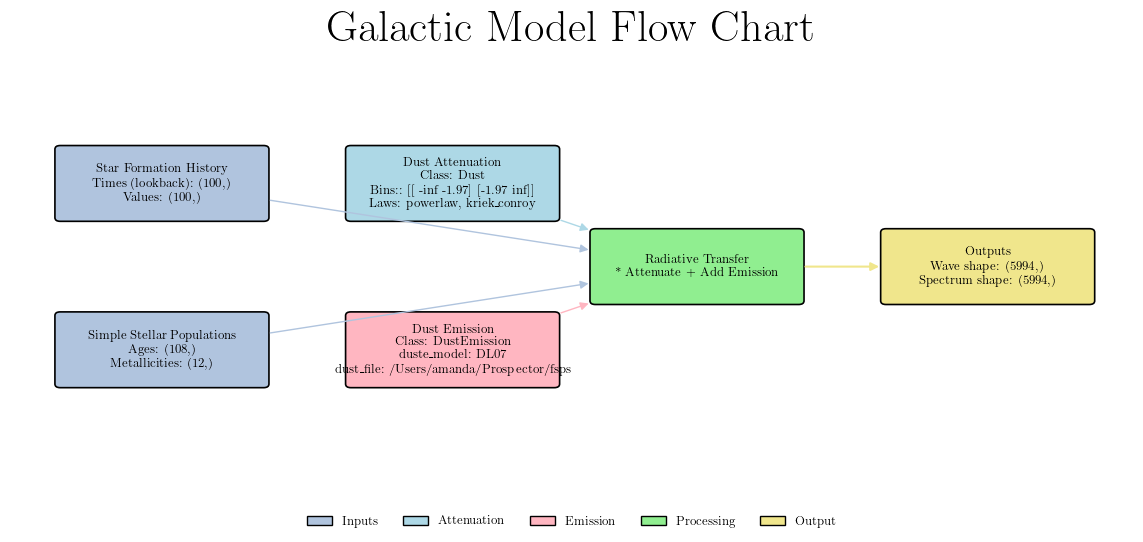

In [25]:
plot_model_structure(csp_emi)
plt.savefig(os.path.join(path_figs, 'flow_csp_emi.png'), dpi=300)

In [26]:
csp_neb.neb_model

<NebularModel>
-----------------------------------
Files:
  Continuum: /Users/amanda/Prospector/fsps/nebular/ZAU_WD_mist.cont
  Lines    : /Users/amanda/Prospector/fsps/nebular/ZAU_WD_mist.lines

Grids & settings:
  CSP λ grid shape        : (5994,)  (nspec=5994)
  smooth_velocity         : True
  nebular_smooth_init     : 2
  nebnz / nebnage / nebnip: 11 / 10 / 7

Continuum cube (log10 L/Q):
  nebem_cont shape        : (5994, 11, 10, 7)  (nspec, nz, nage, nu)
  nebem_logz shape/range  : (11,) ; -1.98 – 0.2
  nebem_age  shape/range  : (10,)  ; 5.699 – 7.301  (log10 yr)
  nebem_logu shape/range  : (7,) ; -4 – -1

Emission lines (log10 L/Q):
  line positions shape    : (166,)  (Å)
  nebem_line shape        : (166, 11, 10, 7)  (nlines, nz, nage, nu)
  neb_res_min shape/range : (166,) ; 0.8999 – 5.7e+04  (Å)

Precomputed line profiles:
  gaussnebarr shape       : (5994, 166)  (nspec, nlines)

Last evaluation buffers (optional):
  conflux shape           : (5994,)
  lineflux shape          